In [1]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']

In [2]:
df = pd.read_csv('data.csv', converters={'附件': ast.literal_eval})

- 「通知人」都有谁？

In [3]:
df['通知人'].value_counts(normalize=True).reset_index()

,通知人,proportion
0,教学运行,0.344
1,实践科,0.214
2,质量办,0.132
3,计划科,0.094
4,教研教改,0.076
5,综合科,0.066
6,教材中心,0.058
7,教学通知,0.014
8,电教中心,0.002


- 附件下载次数与通知人的关系？

In [4]:
df_exploded = df.explode('附件')

In [5]:
def get_download_count(x):
    if isinstance(x, dict):
        return x.get('下载次数', 0)
    return 0

In [6]:
df_exploded['下载次数'] = df_exploded['附件'].apply(get_download_count)

In [7]:
result = df_exploded.groupby('通知人')['下载次数'].sum().reset_index()

In [8]:
result = result.sort_values(by='下载次数', ascending=False)

In [9]:
result

,通知人,下载次数
0,实践科,161152
1,教学运行,124745
7,计划科,49029
4,教研教改,46760
8,质量办,30059
3,教材中心,22342
2,教学通知,3634
6,综合科,3453
5,电教中心,0


<Axes: xlabel='通知人'>

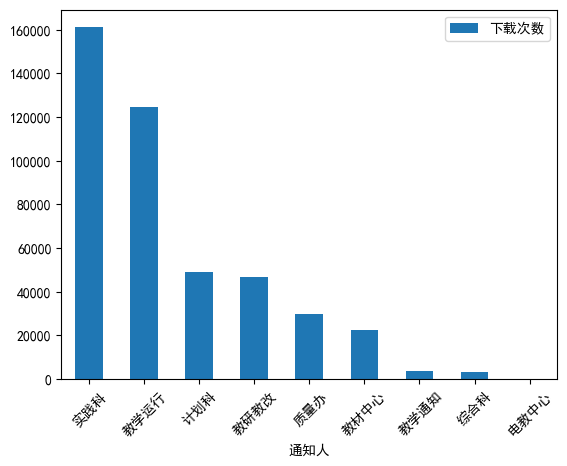

In [10]:
result.set_index('通知人').plot(kind='bar',rot=45)

- 通知发布的高峰期？

In [11]:
df['日期']=pd.to_datetime(df['日期'])
df['年份月份'] = df['日期'].dt.year * 100 + df['日期'].dt.month-200000

In [12]:
m_counts=df.groupby('年份月份').size().sort_index()

<Axes: xlabel='年份月份'>

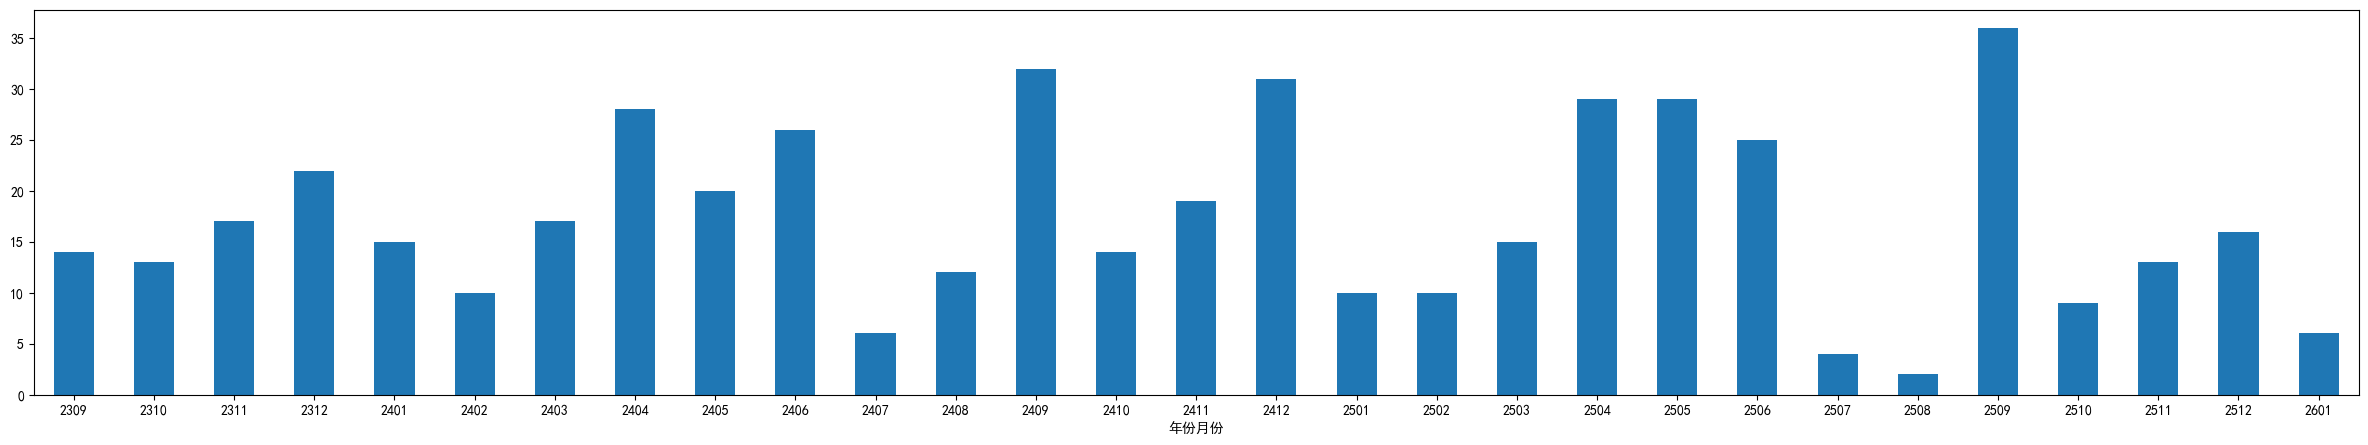

In [13]:
m_counts.plot(kind='bar', figsize=(30, 5),rot=0)

通知更多集中在开学与期末

- 标题长度与平均下载量之间的关系

In [14]:
df['title_len']=df['标题'].str.len()

In [15]:
def sum_downloads(attachments):
    if not attachments: 
        return 0
    return sum(item.get('下载次数', 0) for item in attachments)

In [16]:
df['tot_dl'] = df['附件'].apply(sum_downloads)

In [17]:
title_len_down_times=df.groupby('title_len')['tot_dl'].mean().reset_index()

In [18]:
title_len_down_times=title_len_down_times.set_index('title_len')

In [19]:
title_len_down_times.columns=['avg_dl']

<Axes: xlabel='title_len'>

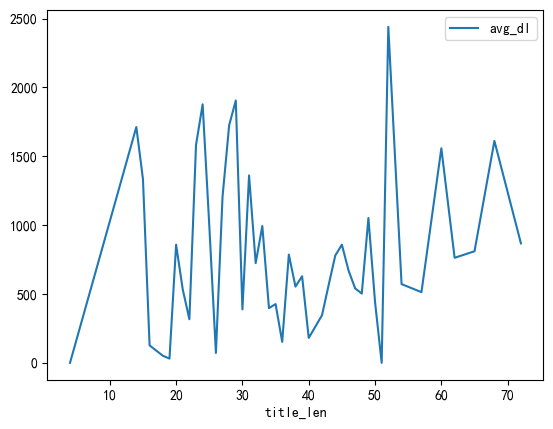

In [20]:
title_len_down_times.plot(kind='line')

In [21]:
bins=[5*i for i in range(20)]

In [22]:
df['title_len_5'] = pd.cut(df['title_len'], bins=bins)

In [23]:
new_df=df.groupby('title_len_5')['tot_dl'].mean().reset_index().set_index('title_len_5')['tot_dl'].fillna(0)

C:\Users\x1879\AppData\Local\Temp\ipykernel_49640\1587517485.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  new_df=df.groupby('title_len_5')['tot_dl'].mean().reset_index().set_index('title_len_5')['tot_dl'].fillna(0)


<Axes: xlabel='title_len_5'>

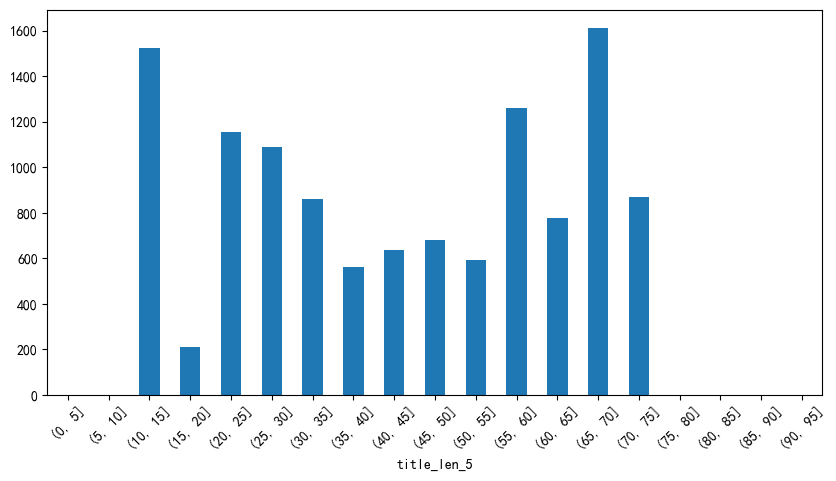

In [24]:
new_df.plot(kind='bar',figsize=(10,5),rot=45)